
Week 4: API Development, Evaluation, and Final Delivery

 Load Everything & Run Final Evaluation

In [1]:


import pandas as pd
import numpy as np
import pickle
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)
from transformers import BertTokenizer, BertForSequenceClassification
from sklearn.preprocessing import LabelEncoder

# --- Load dataset ---
df = pd.read_csv('../data/grievances.csv')

import re
def clean(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['clean_text'] = df['text'].apply(clean)

# --- Load department model ---
with open('../models/tfidf_vectorizer.pkl', 'rb') as f:
    tfidf_dept = pickle.load(f)
with open('../models/dept_classifier.pkl', 'rb') as f:
    dept_model = pickle.load(f)

# --- Load BERT sentiment model ---
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
tokenizer = BertTokenizer.from_pretrained('../models/bert_sentiment/')
bert_model = BertForSequenceClassification.from_pretrained('../models/bert_sentiment/')
bert_model.to(device)
bert_model.eval()

with open('../models/label_encoder.pkl', 'rb') as f:
    le = pickle.load(f)

print("All models loaded successfully!")

C:\Users\Chenna Keshava\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\Chenna Keshava\AppData\Roaming\Python\Python311\site-packages\triton\windows_utils.py:433: UserWarning: Failed to find CUDA.
  warnings.warn("Failed to find CUDA.")
C:\Users\Chenna Keshava\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator TfidfTransformer from version 1.8.0 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Chenna Keshava\AppData\Roaming\Python\Python311\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Tryi

All models loaded successfully!


 Department Model: Confusion Matrix

   DEPARTMENT CLASSIFIER — Classification Report
              precision    recall  f1-score   support

 Electricity       1.00      1.00      1.00        33
  Healthcare       1.00      1.00      1.00        37
       Roads       1.00      1.00      1.00        32
  Sanitation       1.00      1.00      1.00        32
   Transport       1.00      1.00      1.00        34
       Water       1.00      1.00      1.00        32

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



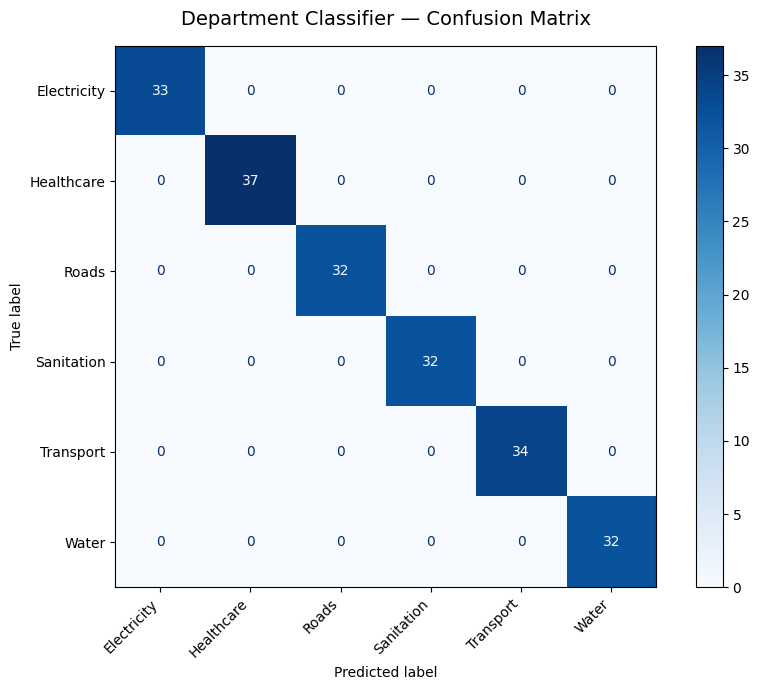

Saved: confusion_department.png


In [2]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y_dept = df['department']

X_train, X_test, y_train, y_test = train_test_split(
    X, y_dept, test_size=0.2, stratify=y_dept, random_state=42
)

X_test_vec = tfidf_dept.transform(X_test)
y_pred_dept = dept_model.predict(X_test_vec)

# --- Classification Report ---
print("=" * 55)
print("   DEPARTMENT CLASSIFIER — Classification Report")
print("=" * 55)
print(classification_report(y_test, y_pred_dept))

# --- Confusion Matrix ---
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dept,
    display_labels=dept_model.classes_,
    cmap='Blues',
    ax=ax
)
ax.set_title('Department Classifier — Confusion Matrix', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/confusion_department.png', dpi=150)
plt.show()
print("Saved: confusion_department.png")

Sentiment Model: Confusion Matrix (BERT)

   BERT SENTIMENT MODEL — Classification Report
                 precision    recall  f1-score   support

Critical/Urgent       1.00      1.00      1.00        62
       Negative       1.00      1.00      1.00       104
        Neutral       1.00      1.00      1.00        34

       accuracy                           1.00       200
      macro avg       1.00      1.00      1.00       200
   weighted avg       1.00      1.00      1.00       200

Macro F1-Score: 1.0000


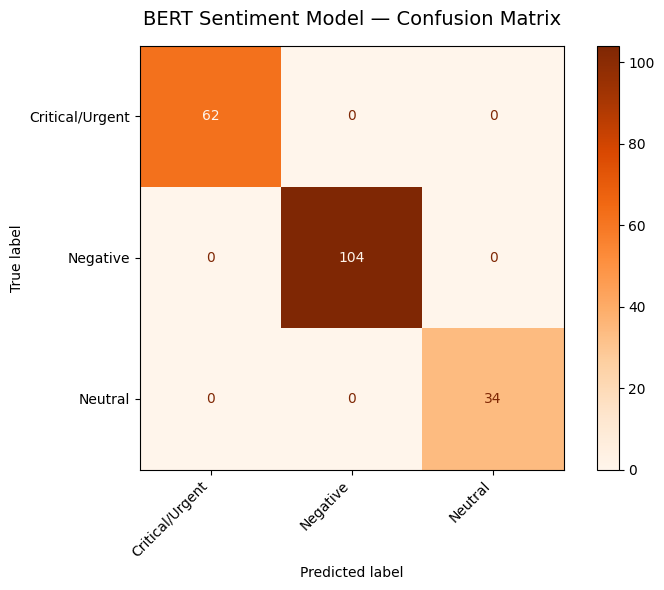

Saved: confusion_sentiment.png


In [3]:
# Run BERT predictions on the test set
y_sent = df['sentiment']
_, X_test_sent, _, y_test_sent = train_test_split(
    df['clean_text'].tolist(),
    y_sent.tolist(),
    test_size=0.2,
    stratify=y_sent,
    random_state=42
)

def bert_predict_batch(texts, batch_size=16):
    all_preds = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc   = tokenizer(
            batch, padding=True, truncation=True,
            max_length=64, return_tensors='pt'
        )
        input_ids      = enc['input_ids'].to(device)
        attention_mask = enc['attention_mask'].to(device)

        with torch.no_grad():
            output = bert_model(input_ids=input_ids,
                                attention_mask=attention_mask)
        preds = torch.argmax(output.logits, dim=1).cpu().numpy()
        all_preds.extend(preds)
    return all_preds

y_pred_sent_idx = bert_predict_batch(X_test_sent)
y_pred_sent     = le.inverse_transform(y_pred_sent_idx)

# --- Classification Report ---
print("=" * 55)
print("   BERT SENTIMENT MODEL — Classification Report")
print("=" * 55)
print(classification_report(y_test_sent, y_pred_sent))
print(f"Macro F1-Score: {f1_score(y_test_sent, y_pred_sent, average='macro'):.4f}")

# --- Confusion Matrix ---
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test_sent, y_pred_sent,
    display_labels=le.classes_,
    cmap='Oranges',
    ax=ax
)
ax.set_title('BERT Sentiment Model — Confusion Matrix', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/confusion_sentiment.png', dpi=150)
plt.show()
print("Saved: confusion_sentiment.png")

Combined Metrics Summary Table

In [4]:
# Nice summary table of all model metrics side by side

from sklearn.metrics import accuracy_score, precision_score, recall_score

dept_acc  = accuracy_score(y_test, y_pred_dept)
dept_f1   = f1_score(y_test, y_pred_dept, average='macro')
dept_prec = precision_score(y_test, y_pred_dept, average='macro')
dept_rec  = recall_score(y_test, y_pred_dept, average='macro')

sent_acc  = accuracy_score(y_test_sent, y_pred_sent)
sent_f1   = f1_score(y_test_sent, y_pred_sent, average='macro')
sent_prec = precision_score(y_test_sent, y_pred_sent, average='macro')
sent_rec  = recall_score(y_test_sent, y_pred_sent, average='macro')

summary = pd.DataFrame({
    'Model':     ['Random Forest (Department)', 'BERT (Sentiment)'],
    'Accuracy':  [f"{dept_acc:.4f}", f"{sent_acc:.4f}"],
    'Precision': [f"{dept_prec:.4f}", f"{sent_prec:.4f}"],
    'Recall':    [f"{dept_rec:.4f}", f"{sent_rec:.4f}"],
    'Macro F1':  [f"{dept_f1:.4f}", f"{sent_f1:.4f}"]
})

print("\n========= FINAL EVALUATION SUMMARY =========")
print(summary.to_string(index=False))


========= FINAL EVALUATION SUMMARY =========
                     Model Accuracy Precision Recall Macro F1
Random Forest (Department)   1.0000    1.0000 1.0000   1.0000
          BERT (Sentiment)   1.0000    1.0000 1.0000   1.0000
